Model Building

In [72]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [74]:
# Step 1: Load Dataset

df = pd.read_csv("training_dataset.csv")

# Basic info
print("Dataset loaded successfully")
print("Total samples:", df.shape[0])
print("Total features:", df.shape[1])

# Show first 5 rows
print("\nDataset preview:")
display(df.head())

# Check class distribution
print("\nClass Distribution:")
print(df["Result"].value_counts())

Dataset loaded successfully
Total samples: 11055
Total features: 32

Dataset preview:


,id,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1



Class Distribution:
Result
 1    6157
-1    4898
Name: count, dtype: int64


In [75]:
# Feature encoding:
# Values -1, 0, 1 represent different conditions depending on the feature.
# Generally, -1 indicates suspicious/phishing behavior, 1 indicates legitimate behavior.

In [76]:
# Check unique values for each column
for col in df.columns:
    print(f"\nFeature: {col}")
    print(df[col].unique())



Feature: id
[    1     2     3 ... 11053 11054 11055]

Feature: having_IP_Address
[-1  1]

Feature: URL_Length
[ 1  0 -1]

Feature: Shortining_Service
[ 1 -1]

Feature: having_At_Symbol
[ 1 -1]

Feature: double_slash_redirecting
[-1  1]

Feature: Prefix_Suffix
[-1  1]

Feature: having_Sub_Domain
[-1  0  1]

Feature: SSLfinal_State
[-1  1  0]

Feature: Domain_registeration_length
[-1  1]

Feature: Favicon
[ 1 -1]

Feature: port
[ 1 -1]

Feature: HTTPS_token
[-1  1]

Feature: Request_URL
[ 1 -1]

Feature: URL_of_Anchor
[-1  0  1]

Feature: Links_in_tags
[ 1 -1  0]

Feature: SFH
[-1  1  0]

Feature: Submitting_to_email
[-1  1]

Feature: Abnormal_URL
[-1  1]

Feature: Redirect
[0 1]

Feature: on_mouseover
[ 1 -1]

Feature: RightClick
[ 1 -1]

Feature: popUpWidnow
[ 1 -1]

Feature: Iframe
[ 1 -1]

Feature: age_of_domain
[-1  1]

Feature: DNSRecord
[-1  1]

Feature: web_traffic
[-1  0  1]

Feature: Page_Rank
[-1  1]

Feature: Google_Index
[ 1 -1]

Feature: Links_pointing_to_page
[ 1  0 -1]


In [78]:
# Step 2: Data Cleaning

# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Since there are no missing values, no need to handle them

# Remove duplicate rows (if any)
df.drop_duplicates(inplace=True)
# Final dataset shape after cleaning
print("\nAfter cleaning:")
print("Total samples:", df.shape[0])
print("Total features:", df.shape[1])

# Data Summary
print("Summary Statistics:")
display(df.describe())


Missing values:
id                             0
having_IP_Address              0
URL_Length                     0
Shortining_Service             0
having_At_Symbol               0
double_slash_redirecting       0
Prefix_Suffix                  0
having_Sub_Domain              0
SSLfinal_State                 0
Domain_registeration_length    0
Favicon                        0
port                           0
HTTPS_token                    0
Request_URL                    0
URL_of_Anchor                  0
Links_in_tags                  0
SFH                            0
Submitting_to_email            0
Abnormal_URL                   0
Redirect                       0
on_mouseover                   0
RightClick                     0
popUpWidnow                    0
Iframe                         0
age_of_domain                  0
DNSRecord                      0
web_traffic                    0
Page_Rank                      0
Google_Index                   0
Links_pointing_to_page     

,id,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
count,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,...,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000
mean,5528.000000,0.313795,-0.633198,0.738761,0.700588,0.741474,-0.734962,0.063953,0.250927,-0.336771,...,0.613388,0.816915,0.061239,0.377114,0.287291,-0.483673,0.721574,0.344007,0.719584,0.113885
std,3191.447947,0.949534,0.766095,0.673998,0.713598,0.671011,0.678139,0.817518,0.911892,0.941629,...,0.789818,0.576784,0.998168,0.926209,0.827733,0.875289,0.692369,0.569944,0.694437,0.993539
min,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,2764.500000,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,1.000000,1.000000,-1.000000,-1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
50%,5528.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,-1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,0.000000,1.000000,1.000000
75%,8291.500000,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,11055.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [79]:
# Step 3: Train-Test Split

# Remove 'id' and target
X = df.drop(["Result", "id"], axis=1)
y = df["Result"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts())
print("\nTest target distribution:")
print(y_test.value_counts())

Training set size: (8844, 30)
Test set size: (2211, 30)

Training target distribution:
Result
 1    4926
-1    3918
Name: count, dtype: int64

Test target distribution:
Result
 1    1231
-1     980
Name: count, dtype: int64


In [80]:
# Step 4: Model Training

# Initialize model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train model
model.fit(X_train, y_train)
print("Model training completed successfully")
print("Number of features used:", X_train.shape[1])

Model training completed successfully
Number of features used: 30


In [81]:
# Step 5: Model Evaluation

# Predictions
y_pred = model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

# Print results
print("Model Evaluation Results:")
print(f"Accuracy  : {accuracy:.2%}")
print(f"Precision : {precision:.2%}")
print(f"Recall    : {recall:.2%}")
print(f"F1 Score  : {f1:.2%}")

Model Evaluation Results:
Accuracy  : 97.42%
Precision : 96.96%
Recall    : 98.46%
F1 Score  : 97.70%


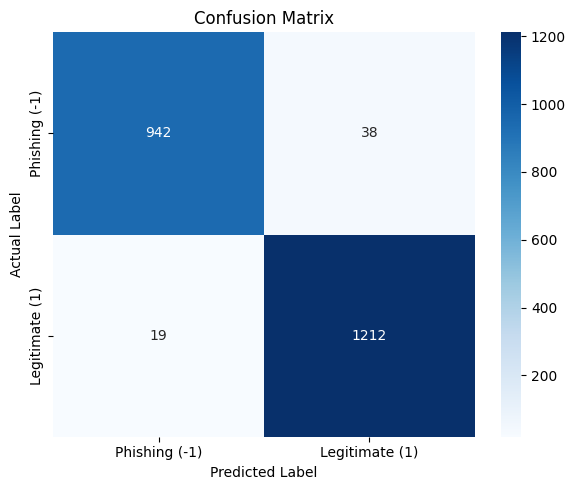

In [82]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Phishing (-1)', 'Legitimate (1)'],
            yticklabels=['Phishing (-1)', 'Legitimate (1)'])

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

In [85]:
#  Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

          -1       0.98      0.96      0.97       980
           1       0.97      0.98      0.98      1231

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



Prediction


In [ ]:
!pip install python-whois

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 4.9 MB/s eta 0:00:00


In [ ]:
!pip install beautifulsoup4

In [86]:
import re
from urllib.parse import urlparse
import requests
import whois
from datetime import datetime
from bs4 import BeautifulSoup
import socket

In [87]:
def having_ip_address(url):
    # Check for IPv4 address
    if re.search(r'\d+\.\d+\.\d+\.\d+', url):
        return -1

    # Check for hexadecimal IP (like 0x58.0xCC...)
    if re.search(r'0x[0-9a-fA-F]+', url):
        return -1

    return 1

def url_length_feature(url):
    length = len(url)

    if length < 54:
        return 1
    elif 54 <= length <= 75:
        return 0
    else:
        return -1

def shortening_service_feature(url):
    shortening_services = [
    "bit.ly", "tinyurl.com", "goo.gl", "t.co", "ow.ly",
    "is.gd", "buff.ly", "adf.ly", "bit.do", "cutt.ly",
    "shorturl.at", "rb.gy", "rebrand.ly"
]

    if any(service in url for service in shortening_services):
        return -1
    else:
        return 1

def having_at_symbol_feature(url):
    if "@" in url:
        return -1
    else:
        return 1

def double_slash_redirecting_feature(url):
    # Find last occurrence of '//'
    last_double_slash = url.rfind('//')

    # Check expected position
    if url.startswith("https"):
        if last_double_slash > 7:
            return -1
    else:
        if last_double_slash > 6:
            return -1

    return 1

def prefix_suffix_feature(url):
    domain = urlparse(url).netloc

    if '-' in domain:
        return -1
    else:
        return 1

def having_sub_domain_feature(url):
    domain = urlparse(url).netloc

    # Remove 'www.'
    if domain.startswith("www."):
        domain = domain[4:]

    # Count dots
    dot_count = domain.count('.')

    if dot_count == 1:
        return 1      # no subdomain
    elif dot_count == 2:
        return 0      # one subdomain
    else:
        return -1     # multiple subdomains

def sslfinal_state_feature(url):
    try:
        if not url.startswith("http"):
            url = "http://" + url

        response = requests.get(url, timeout=5)

        if response.url.startswith("https"):
            return 1
        else:
            return -1
    except:
        return -1

def domain_registration_length_feature(url):
    try:
        domain = urlparse(url).netloc

        # Remove 'www.'
        if domain.startswith("www."):
            domain = domain[4:]

        domain_info = whois.whois(domain)

        creation_date = domain_info.creation_date
        expiration_date = domain_info.expiration_date

        # Handle list format (sometimes WHOIS returns list)
        if isinstance(creation_date, list):
            creation_date = creation_date[0]
        if isinstance(expiration_date, list):
            expiration_date = expiration_date[0]

        # If any value is missing
        if creation_date is None or expiration_date is None:
            return -1

        # Calculate registration length
        duration = (expiration_date - creation_date).days

        if duration >= 365:
            return 1
        else:
            return -1

    except:
        return -1  # If WHOIS fails

def favicon_feature(url):
    try:
        # Normalize URL
        if not url.startswith(("http://", "https://")):
            url = "http://" + url

        domain = urlparse(url).netloc

        response = requests.get(url, timeout=5)
        soup = BeautifulSoup(response.text, "html.parser")

        # Find favicon link
        icon_link = soup.find("link", rel=lambda x: x and "icon" in x.lower())

        if icon_link and icon_link.get("href"):
            favicon_url = icon_link.get("href")

            # Check if favicon URL belongs to same domain
            if domain in favicon_url or favicon_url.startswith("/"):
                return 1
            else:
                return -1

        return 1  # No favicon found → assume safe

    except:
        return -1

def port_feature(url):
    try:
        parsed = urlparse(url)

        # If no port is specified → default → safe
        if parsed.port is None:
            return 1

        # Check standard ports
        if parsed.port in [80, 443]:
            return 1
        else:
            return -1

    except:
        return -1

def https_token_feature(url):
    domain = urlparse(url).netloc.lower()

    if "https" in domain:
        return -1
    else:
        return 1

def request_url_feature(url):
    try:
        if not url.startswith(("http://", "https://")):
            url = "http://" + url

        domain = urlparse(url).netloc

        response = requests.get(url, timeout=5)
        soup = BeautifulSoup(response.text, "html.parser")

        tags = soup.find_all(['img', 'audio', 'embed', 'iframe'])

        total = len(tags)
        external = 0

        for tag in tags:
            src = tag.get('src')
            if src:
                if domain not in src and not src.startswith('/'):
                    external += 1

        if total == 0:
            return 1  # no resources → assume safe

        percentage = external / total

        if percentage < 0.22:
            return 1
        else:
            return -1

    except:
        return -1

def url_of_anchor_feature(url):
    try:
        if not url.startswith(("http://", "https://")):
            url = "http://" + url

        domain = urlparse(url).netloc

        response = requests.get(url, timeout=5)
        soup = BeautifulSoup(response.text, "html.parser")

        anchors = soup.find_all('a')

        total = len(anchors)
        unsafe = 0

        for tag in anchors:
            href = tag.get('href')

            if href:
                # Empty or unsafe links
                if href.startswith("#") or \
                   href.lower().startswith("javascript") or \
                   href.lower().startswith("mailto"):
                    unsafe += 1

                # External domain
                elif domain not in href and not href.startswith('/'):
                    unsafe += 1

        if total == 0:
            return 1

        percentage = unsafe / total

        if percentage < 0.31:
            return 1
        elif percentage <= 0.67:
            return 0
        else:
            return -1

    except:
        return -1

def links_in_tags_feature(url):
    try:
        if not url.startswith(("http://", "https://")):
            url = "http://" + url

        domain = urlparse(url).netloc

        response = requests.get(url, timeout=5)
        soup = BeautifulSoup(response.text, "html.parser")

        tags = (
            soup.find_all('meta') +
            soup.find_all('script') +
            soup.find_all('link')
        )

        total = len(tags)
        external = 0

        for tag in tags:
            src = tag.get('src') or tag.get('href')

            if src:
                if domain not in src and not src.startswith('/'):
                    external += 1

        if total == 0:
            return 1

        percentage = external / total

        if percentage < 0.17:
            return 1
        elif percentage <= 0.81:
            return 0
        else:
            return -1

    except:
        return -1

def sfh_feature(url):
    try:
        if not url.startswith(("http://", "https://")):
            url = "http://" + url

        domain = urlparse(url).netloc

        response = requests.get(url, timeout=5)
        soup = BeautifulSoup(response.text, "html.parser")

        forms = soup.find_all('form')

        if len(forms) == 0:
            return 1  # no forms → assume safe

        for form in forms:
            action = form.get('action')

            if action is None or action == "" or action.lower() == "about:blank":
                return -1  # phishing

            # Check external domain
            elif domain not in action and not action.startswith('/'):
                return 0  # suspicious

        return 1  # safe

    except:
        return -1

def submitting_to_email_feature(url):
    try:
        if not url.startswith(("http://", "https://")):
            url = "http://" + url

        response = requests.get(url, timeout=5)
        soup = BeautifulSoup(response.text, "html.parser")

        # Check forms
        forms = soup.find_all('form')

        for form in forms:
            action = form.get('action')
            if action and "mailto:" in action.lower():
                return -1

        # Check page content (extra safety)
        if "mailto:" in response.text.lower():
            return -1

        return 1

    except:
        return -1

def abnormal_url_feature(url):
    try:
        domain = urlparse(url).netloc

        if domain.startswith("www."):
            domain = domain[4:]

        domain_info = whois.whois(domain)

        # If no WHOIS info → phishing
        if domain_info.domain_name is None:
            return -1

        return 1

    except:
        return -1

def redirect_feature(url):
    try:
        if not url.startswith(("http://", "https://")):
            url = "http://" + url

        response = requests.get(url, timeout=5)

        # Count redirects
        redirect_count = len(response.history)

        if redirect_count <= 1:
            return 1
        else:
            return 0

    except:
        return 0

def on_mouseover_feature(url):
    try:
        if not url.startswith(("http://", "https://")):
            url = "http://" + url

        response = requests.get(url, timeout=5)
        content = response.text.lower()

        # Check for suspicious onmouseover behavior
        if "onmouseover" in content:
            return -1
        else:
            return 1

    except:
        return -1

def right_click_feature(url):
    try:
        if not url.startswith(("http://", "https://")):
            url = "http://" + url

        response = requests.get(url, timeout=5)
        content = response.text.lower()

        # Check for right-click disable script
        if "event.button==2" in content or "contextmenu" in content:
            return -1
        else:
            return 1

    except:
        return -1

def popup_window_feature(url):
    try:
        if not url.startswith(("http://", "https://")):
            url = "http://" + url

        response = requests.get(url, timeout=5)
        content = response.text.lower()

        # Check for popup-related JavaScript
        if "alert(" in content or "prompt(" in content or "confirm(" in content:
            return -1
        else:
            return 1

    except:
        return -1

def iframe_feature(url):
    try:
        if not url.startswith(("http://", "https://")):
            url = "http://" + url

        response = requests.get(url, timeout=5)
        soup = BeautifulSoup(response.text, "html.parser")

        iframes = soup.find_all("iframe")

        for iframe in iframes:
            # Check for hidden iframe
            if iframe.get("frameborder") == "0" or iframe.get("width") == "0" or iframe.get("height") == "0":
                return -1

        if len(iframes) > 0:
            return -1  # iframe exists → suspicious

        return 1

    except:
        return -1

def age_of_domain_feature(url):
    try:
        domain = urlparse(url).netloc

        # Remove 'www.'
        if domain.startswith("www."):
            domain = domain[4:]

        domain_info = whois.whois(domain)

        creation_date = domain_info.creation_date

        # Handle list format
        if isinstance(creation_date, list):
            creation_date = creation_date[0]

        if creation_date is None:
            return -1

        # Calculate age
        today = datetime.now()
        age_days = (today - creation_date).days

        if age_days >= 180:
            return 1
        else:
            return -1

    except:
        return -1

def dns_record_feature(url):
    try:
        domain = urlparse(url).netloc

        # Remove 'www.'
        if domain.startswith("www."):
            domain = domain[4:]

        # Try resolving domain
        socket.gethostbyname(domain)

        return 1  # DNS exists

    except:
        return -1  # No DNS

def web_traffic_feature(url):
    try:
        if not url.startswith(("http://", "https://")):
            url = "http://" + url

        response = requests.get(url, timeout=5)

        # If site is reachable → assume some traffic
        if response.status_code == 200:
            return 0  # Suspicious (unknown traffic)
        else:
            return -1

    except:
        return -1

def page_rank_feature(url):
    try:
        if not url.startswith(("http://", "https://")):
            url = "http://" + url

        response = requests.get(url, timeout=5)

        if response.status_code == 200:
            return 1  # assume some authority
        else:
            return -1

    except:
        return -1

def google_index_feature(url):
    try:
        if not url.startswith(("http://", "https://")):
            url = "http://" + url

        # Search in Google
        query = "https://www.google.com/search?q=site:" + url
        response = requests.get(query, timeout=5)

        # If results found → indexed
        if "did not match any documents" in response.text.lower():
            return -1
        else:
            return 1

    except:
        return -1

def links_pointing_to_page_feature(url):
    try:
        if not url.startswith(("http://", "https://")):
            url = "http://" + url

        domain = urlparse(url).netloc

        response = requests.get(url, timeout=5)
        soup = BeautifulSoup(response.text, "html.parser")

        anchors = soup.find_all('a')

        count = 0

        for tag in anchors:
            href = tag.get('href')
            if href and domain in href:
                count += 1

        # Apply rule
        if count == 0:
            return -1
        elif count <= 2:
            return 0
        else:
            return 1

    except:
        return -1

def statistical_report_feature(url):
    try:
        domain = urlparse(url).netloc

        # Example blacklist (can expand)
        phishing_domains = [
            "phishing.com",
            "malicious.com",
            "badsite.com"
        ]

        # Check domain
        for bad in phishing_domains:
            if bad in domain:
                return -1

        # Check IP pattern (known bad IP ranges example)
        if re.search(r'192\.168\.', domain):
            return -1

        return 1

    except:
        return -1

In [91]:
def predict_url(url):
    features = []

    # Address bar features
    features.append(having_ip_address(url))
    features.append(url_length_feature(url))
    features.append(shortening_service_feature(url))
    features.append(having_at_symbol_feature(url))
    features.append(double_slash_redirecting_feature(url))
    features.append(prefix_suffix_feature(url))
    features.append(having_sub_domain_feature(url))
    features.append(sslfinal_state_feature(url))
    features.append(domain_registration_length_feature(url))
    features.append(favicon_feature(url))
    features.append(port_feature(url))
    features.append(https_token_feature(url))

    # Abnormal features
    features.append(request_url_feature(url))
    features.append(url_of_anchor_feature(url))
    features.append(links_in_tags_feature(url))
    features.append(sfh_feature(url))
    features.append(submitting_to_email_feature(url))
    features.append(abnormal_url_feature(url))

    # HTML & JS features
    features.append(redirect_feature(url))
    features.append(on_mouseover_feature(url))
    features.append(right_click_feature(url))
    features.append(popup_window_feature(url))
    features.append(iframe_feature(url))

    # Domain features
    features.append(age_of_domain_feature(url))
    features.append(dns_record_feature(url))
    features.append(web_traffic_feature(url))
    features.append(page_rank_feature(url))
    features.append(google_index_feature(url))
    features.append(links_pointing_to_page_feature(url))
    features.append(statistical_report_feature(url))

    features_df = pd.DataFrame([features], columns=X.columns)

    prediction = model.predict(features_df)[0]

    if prediction == 1:
        return "Legitimate Website"
    else:
        return "Phishing Website"

url = input("Enter URL: ")
print("\nPrediction:", predict_url(url))

Enter URL: https://which0x0044.firebaseapp.com/

Prediction: Legitimate Website
